In [1]:
import pandas as pd
import pandas as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder 

#### Membuka dadtaset

In [2]:
pd.set_option('display.max_columns', None)
ai_stu_2 = pd.read_csv('ai_student_impact_clean.csv')

In [3]:
ai_stu_2.head()

,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level,major_category_num,primary_use_case_num,paid_subscription_num,institutional_policy_num,year_of_study_num,prompt_engineering_skill_num,burnout_risk_level_num
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,2,0,1,1,3,0,2
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,3,3,0,1,2,2,0
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,1,4,0,2,0,0,1
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,1,0,0,1,3,2,1
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,4,1,0,1,1,2,1


##### EDA

In [4]:
#melakukan analisa menggunakan tableu
import pygwalker as pyg 

In [7]:
pyg.walk(ai_stu_2, dark='light')

Box(children=(HTML(value='\n<div id="ifr-pyg-000653d18f40a4bdPytX4coJ1I8iEFd9" style="height: auto">\n    <hea…

In [8]:
ai_stu_2.head()

,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level,major_category_num,primary_use_case_num,paid_subscription_num,institutional_policy_num,year_of_study_num,prompt_engineering_skill_num,burnout_risk_level_num
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,2,0,1,1,3,0,2
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,3,3,0,1,2,2,0
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,1,4,0,2,0,0,1
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,1,0,0,1,3,2,1
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,4,1,0,1,1,2,1


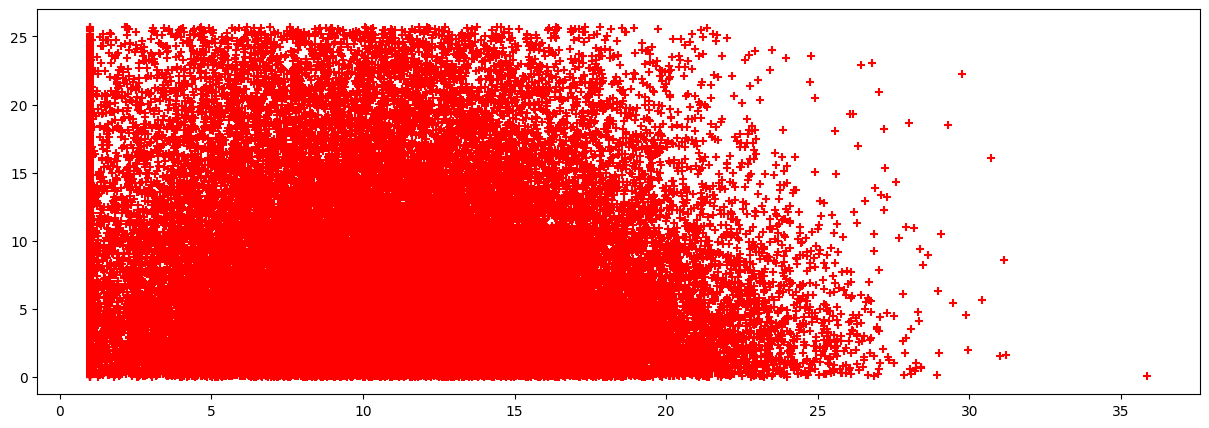

In [5]:
plt.figure(figsize=(15,5))
x = ai_stu_2['traditional_study_hours']
y = ai_stu_2['weekly_genai_hours']
plt.scatter(x,y, marker="+", color = 'red')



#### Memisahkan Test train

In [6]:
ai_stu_2.head()

,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level,major_category_num,primary_use_case_num,paid_subscription_num,institutional_policy_num,year_of_study_num,prompt_engineering_skill_num,burnout_risk_level_num
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,2,0,1,1,3,0,2
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,3,3,0,1,2,2,0
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,1,4,0,2,0,0,1
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,1,0,0,1,3,2,1
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,4,1,0,1,1,2,1


In [7]:
ai_stu_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47284 entries, 0 to 47283
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   major_category                47284 non-null  object 
 1   year_of_study                 47284 non-null  object 
 2   pre_semester_gpa              47284 non-null  float64
 3   weekly_genai_hours            47284 non-null  float64
 4   primary_use_case              47284 non-null  object 
 5   prompt_engineering_skill      47284 non-null  object 
 6   tool_diversity                47284 non-null  int64  
 7   paid_subscription             47284 non-null  bool   
 8   traditional_study_hours       47284 non-null  float64
 9   perceived_ai_dependency       47284 non-null  int64  
 10  institutional_policy          47284 non-null  object 
 11  anxiety_level_during_exams    47284 non-null  int64  
 12  post_semester_gpa             47284 non-null  float64
 13  s

In [8]:
from sklearn.model_selection import train_test_split

In [10]:
target = ['post_semester_gpa']
features = ['pre_semester_gpa', 'weekly_genai_hours','tool_diversity',
             'traditional_study_hours', 'perceived_ai_dependency', 'anxiety_level_during_exams',
             'skill_retention_score', 'major_category_num', 'primary_use_case_num',
             'paid_subscription_num', 'institutional_policy_num', 'year_of_study_num',
             'prompt_engineering_skill_num','burnout_risk_level_num' ]

X = ai_stu_2[features]
y = ai_stu_2[target]


In [11]:
#melakukan trainn test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42
)

y_train = y_train.values.ravel() # mengubah (n,1) → (n,)
y_test = y_test.values.ravel()


print("\n")
print("="*60)
print('Train test shape')
print("="*60)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)



Train test shape
X_train : (37827, 14)
X_test : (9457, 14)
y_train : (37827,)
y_test : (9457,)


##### Membuat Pipeline

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [13]:
from sklearn.pipeline import Pipeline


from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline

In [14]:
scalers = [
    ('standard', StandardScaler()),
    ('minmax', MinMaxScaler()),
    ('maxabs', MaxAbsScaler())
]

imputers = [
    ('simple', SimpleImputer(strategy='median')),
    ('knn', KNNImputer(n_neighbors=5))
]

models = [
    ('Linier Regression', LinearRegression()),
    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('XGBoost', XGBRegressor(n_estimators=100, random_state=42))
]

In [15]:
pipeline_to_try = []

for scaler_name, scaler in scalers:
    for imputer_name, imputer in imputers:
        for model_name, model in models :
            pipeline= Pipeline([
                (imputer_name, imputer),
                (scaler_name, scaler),
                ('classifier', model)
            ])
            pipeline_to_try.append((f"{model_name} with {imputer_name} and {scaler_name}",pipeline))

In [16]:
len(pipeline_to_try)

18

In [17]:
names = []
for name, pipeline in pipeline_to_try:
    names.append(name)

names.sort()
for name in names:
    print(name)

Linier Regression with knn and maxabs
Linier Regression with knn and minmax
Linier Regression with knn and standard
Linier Regression with simple and maxabs
Linier Regression with simple and minmax
Linier Regression with simple and standard
Random Forest with knn and maxabs
Random Forest with knn and minmax
Random Forest with knn and standard
Random Forest with simple and maxabs
Random Forest with simple and minmax
Random Forest with simple and standard
XGBoost with knn and maxabs
XGBoost with knn and minmax
XGBoost with knn and standard
XGBoost with simple and maxabs
XGBoost with simple and minmax
XGBoost with simple and standard


##### Melatih Model

In [23]:
train_result = []

for name, pipeline in pipeline_to_try :
    #melatih model
    pipeline.fit(X_train, y_train)
    
    #prediksi
    y_pred = pipeline.predict(X_test)
    #y_pred_proba = pipeline.predict_proba(X_test)
    
    MAE = mean_absolute_error(y_test, y_pred)
    R2 = r2_score(y_test, y_pred)

    train_result.append({
        'Nama Pipline' : name,
        'R2_Score' : R2,
        'MAE' : MAE
    })
    
    print("="*50)
    print(f"✅ {name} Pipeline MAE :{(MAE):.4f} ({MAE*100:.2f}%) ")
    print(f"✅ {name} Pipeline R2 :{(R2):.4f} ({R2*100:.2f}%) ")

df_train_result = pd.DataFrame(train_result)
    

✅ Linier Regression with simple and standard Pipeline MAE :0.1240 (12.40%) 
✅ Linier Regression with simple and standard Pipeline R2 :0.8974 (89.74%) 
✅ Random Forest with simple and standard Pipeline MAE :0.1213 (12.13%) 
✅ Random Forest with simple and standard Pipeline R2 :0.8999 (89.99%) 
✅ XGBoost with simple and standard Pipeline MAE :0.1182 (11.82%) 
✅ XGBoost with simple and standard Pipeline R2 :0.9059 (90.59%) 
✅ Linier Regression with knn and standard Pipeline MAE :0.1240 (12.40%) 
✅ Linier Regression with knn and standard Pipeline R2 :0.8974 (89.74%) 
✅ Random Forest with knn and standard Pipeline MAE :0.1213 (12.13%) 
✅ Random Forest with knn and standard Pipeline R2 :0.8999 (89.99%) 
✅ XGBoost with knn and standard Pipeline MAE :0.1182 (11.82%) 
✅ XGBoost with knn and standard Pipeline R2 :0.9059 (90.59%) 
✅ Linier Regression with simple and minmax Pipeline MAE :0.1240 (12.40%) 
✅ Linier Regression with simple and minmax Pipeline R2 :0.8974 (89.74%) 
✅ Random Forest with 

In [ ]:
df_train_result.head(10).sort_values('R2_Score', ascending=False)

,Nama Pipline,R2_Score,MAE
5,XGBoost with knn and standard,0.905921,0.118191
2,XGBoost with simple and standard,0.905921,0.118191
8,XGBoost with simple and minmax,0.905921,0.118191
7,Random Forest with simple and minmax,0.899907,0.121210
4,Random Forest with knn and standard,0.899892,0.121257
1,Random Forest with simple and standard,0.899892,0.121257
0,Linier Regression with simple and standard,0.897379,0.124024
3,Linier Regression with knn and standard,0.897379,0.124024
6,Linier Regression with simple and minmax,0.897379,0.124024
9,Linier Regression with knn and minmax,0.897379,0.124024


#### Mencari tahu Ferature yang aling berpengaruh terhadap Target

Feature Importance (XGBoost - gain):
                         feature  importance_gain
0               pre_semester_gpa         0.846001
11             year_of_study_num         0.034932
3        traditional_study_hours         0.026724
8           primary_use_case_num         0.023684
12  prompt_engineering_skill_num         0.012971
2                 tool_diversity         0.008407
1             weekly_genai_hours         0.008262
10      institutional_policy_num         0.008085
6          skill_retention_score         0.007552
9          paid_subscription_num         0.005576
7             major_category_num         0.004659
13        burnout_risk_level_num         0.004435
5     anxiety_level_during_exams         0.004428
4        perceived_ai_dependency         0.004282


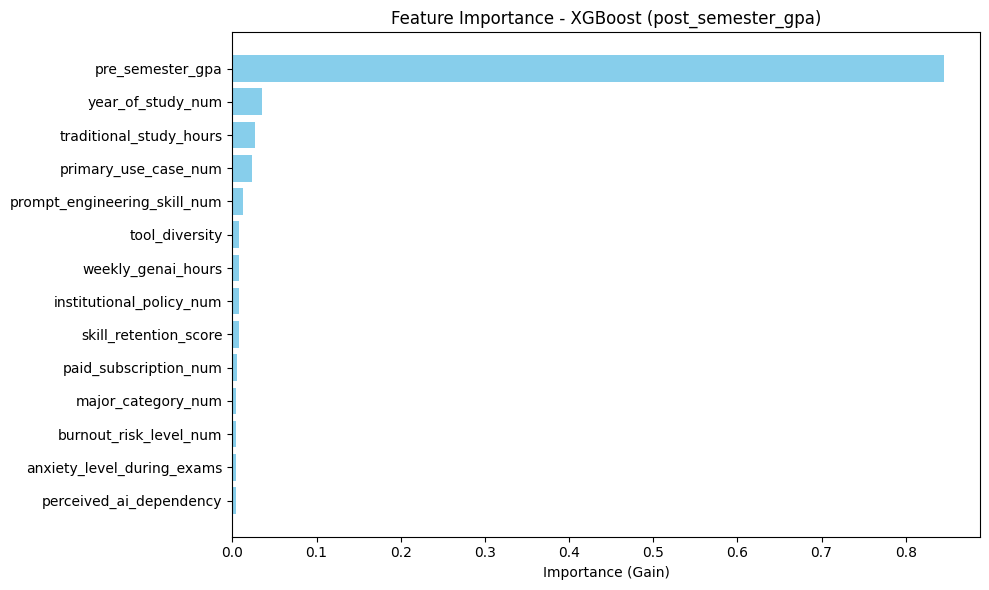

In [32]:
model = ["XGBoost with simple and standard"]

for name , pipeline in pipeline_to_try:
    if name in model :
        aa = pipeline.fit(X_train, y_train)
        # Ambil classifier dari pipeline
        xgb_model = aa.named_steps['classifier']
        # Feature importance (gain)
        importance_gain = xgb_model.feature_importances_
        # Feature importance (weight) - jumlah kali fitur digunakan untuk splitting
        importance_weight = xgb_model.get_booster().get_score(importance_type='weight')
        # Untuk gain, sudah ada di feature_importances_

        # Nama fitur (urutan sesuai training)
        feature_names = [
            'pre_semester_gpa', 'weekly_genai_hours', 'tool_diversity',
            'traditional_study_hours', 'perceived_ai_dependency', 'anxiety_level_during_exams',
            'skill_retention_score', 'major_category_num', 'primary_use_case_num',
            'paid_subscription_num', 'institutional_policy_num', 'year_of_study_num',
            'prompt_engineering_skill_num', 'burnout_risk_level_num'
        ]

        # Buat DataFrame importance
        imp_df = pd.DataFrame({
            'feature': feature_names,
            'importance_gain': importance_gain
        }).sort_values('importance_gain', ascending=False)

        print("Feature Importance (XGBoost - gain):")
        print(imp_df)

        # Plot
        plt.figure(figsize=(10,6))
        plt.barh(imp_df['feature'], imp_df['importance_gain'], color='skyblue')
        plt.xlabel('Importance (Gain)')
        plt.title('Feature Importance - XGBoost (post_semester_gpa)')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()





#### Menyimpan Model

In [30]:
import joblib

# Pilih model yang diinginkan
target_models = [
    "Linier Regression with simple and standard",
    "Random Forest with simple and standard", 
    "XGBoost with simple and standard"
]

for name, pipeline in pipeline_to_try:
    if name in target_models:
        # Latih ulang pipeline (fit) dengan data training
        pipeline.fit(X_train, y_train)
        
        # Simpan ke file .pkl
        filename = name.replace(" ", "_").lower() + ".pkl"
        joblib.dump(pipeline, filename)
        print(f"✅ {name} telah dilatih dan disimpan sebagai {filename}")

✅ Linier Regression with simple and standard telah dilatih dan disimpan sebagai linier_regression_with_simple_and_standard.pkl
✅ Random Forest with simple and standard telah dilatih dan disimpan sebagai random_forest_with_simple_and_standard.pkl
✅ XGBoost with simple and standard telah dilatih dan disimpan sebagai xgboost_with_simple_and_standard.pkl


#### Menganilisa Pentingnya Tiap-Tiap Feature

XGBoost Feature Importance (Gain)
                     feature  importance_gain
            pre_semester_gpa         0.846001
           year_of_study_num         0.034932
     traditional_study_hours         0.026724
        primary_use_case_num         0.023684
prompt_engineering_skill_num         0.012971
              tool_diversity         0.008407
          weekly_genai_hours         0.008262
    institutional_policy_num         0.008085
       skill_retention_score         0.007552
       paid_subscription_num         0.005576
          major_category_num         0.004659
      burnout_risk_level_num         0.004435
  anxiety_level_during_exams         0.004428
     perceived_ai_dependency         0.004282


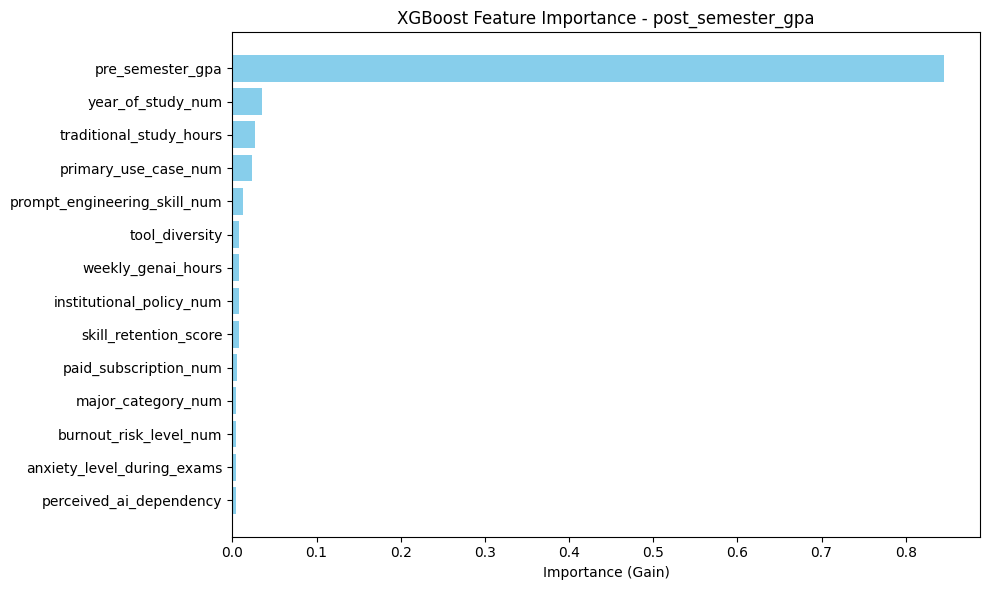


Random Forest Feature Importance (Gini)
                     feature  importance_rf
            pre_semester_gpa       0.883474
     traditional_study_hours       0.035491
          weekly_genai_hours       0.017539
       skill_retention_score       0.016866
           year_of_study_num       0.009977
  anxiety_level_during_exams       0.006922
     perceived_ai_dependency       0.005604
        primary_use_case_num       0.005378
              tool_diversity       0.004954
          major_category_num       0.004676
    institutional_policy_num       0.003070
      burnout_risk_level_num       0.002700
       paid_subscription_num       0.001772
prompt_engineering_skill_num       0.001577


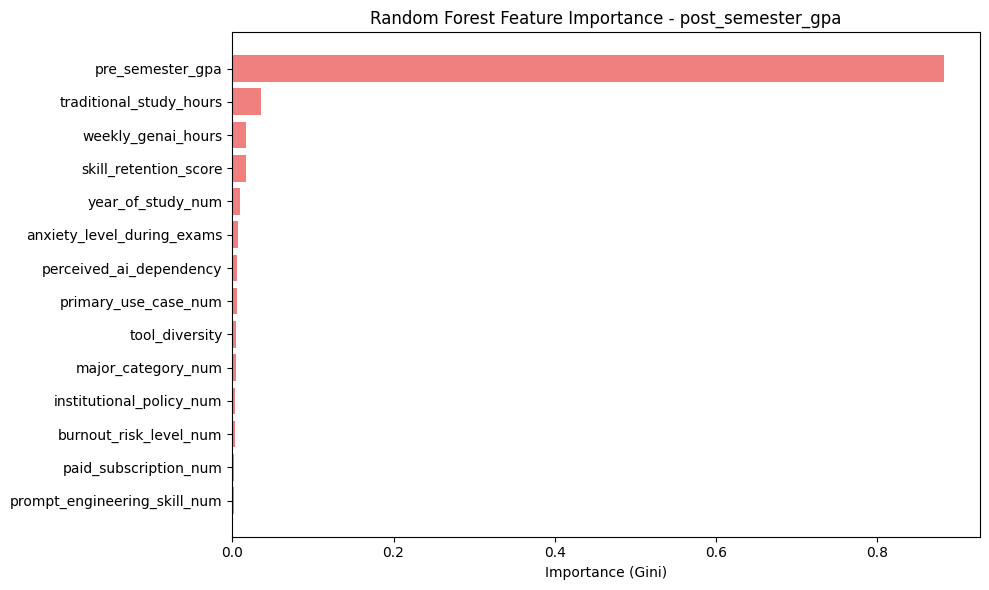


Linear Regression Coefficients (after StandardScaler)
                     feature  coefficient
            pre_semester_gpa     0.457122
          weekly_genai_hours     0.457122
              tool_diversity     0.457122
     traditional_study_hours     0.457122
     perceived_ai_dependency     0.457122
  anxiety_level_during_exams     0.457122
       skill_retention_score     0.457122
          major_category_num     0.457122
        primary_use_case_num     0.457122
       paid_subscription_num     0.457122
    institutional_policy_num     0.457122
           year_of_study_num     0.457122
prompt_engineering_skill_num     0.457122
      burnout_risk_level_num     0.457122


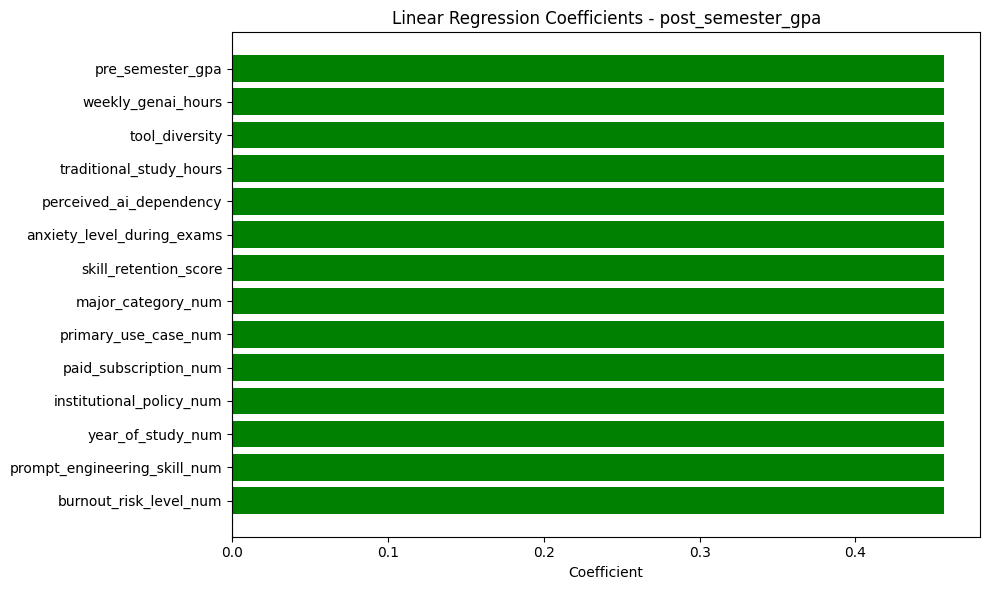


Rangkuman Top 5 Fitur Paling Berpengaruh
XGBoost (Gain):       ['pre_semester_gpa', 'year_of_study_num', 'traditional_study_hours', 'primary_use_case_num', 'prompt_engineering_skill_num']
Random Forest (Gini): ['pre_semester_gpa', 'traditional_study_hours', 'weekly_genai_hours', 'skill_retention_score', 'year_of_study_num']
Linear Regression (|coef|): ['pre_semester_gpa', 'weekly_genai_hours', 'tool_diversity', 'traditional_study_hours', 'perceived_ai_dependency']

Fitur yang masuk Top 5 di ketiga metode: {'traditional_study_hours', 'pre_semester_gpa'}


In [33]:
# ============================================================================
# Analisis Feature Importance untuk Prediksi post_semester_gpa
# ============================================================================
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Nama fitur sesuai urutan training
feature_names = [
    'pre_semester_gpa', 'weekly_genai_hours', 'tool_diversity',
    'traditional_study_hours', 'perceived_ai_dependency', 'anxiety_level_during_exams',
    'skill_retention_score', 'major_category_num', 'primary_use_case_num',
    'paid_subscription_num', 'institutional_policy_num', 'year_of_study_num',
    'prompt_engineering_skill_num', 'burnout_risk_level_num'
]

# ----------------------------------------------------------------------------
# 1. XGBoost Feature Importance (Gain)
# ----------------------------------------------------------------------------
xgb_pipeline = joblib.load("xgboost_with_simple_and_standard.pkl")
xgb_model = xgb_pipeline.named_steps['classifier']

imp_gain = xgb_model.feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance_gain': imp_gain})
imp_df = imp_df.sort_values('importance_gain', ascending=False)

print("="*60)
print("XGBoost Feature Importance (Gain)")
print("="*60)
print(imp_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(imp_df['feature'], imp_df['importance_gain'], color='skyblue')
plt.xlabel('Importance (Gain)')
plt.title('XGBoost Feature Importance - post_semester_gpa')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 2. Random Forest Feature Importance (Gini Importance)
# ----------------------------------------------------------------------------
rf_pipeline = joblib.load("random_forest_with_simple_and_standard.pkl")
rf_model = rf_pipeline.named_steps['classifier']

imp_rf = rf_model.feature_importances_
rf_df = pd.DataFrame({'feature': feature_names, 'importance_rf': imp_rf})
rf_df = rf_df.sort_values('importance_rf', ascending=False)

print("\n" + "="*60)
print("Random Forest Feature Importance (Gini)")
print("="*60)
print(rf_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(rf_df['feature'], rf_df['importance_rf'], color='lightcoral')
plt.xlabel('Importance (Gini)')
plt.title('Random Forest Feature Importance - post_semester_gpa')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 3. Linear Regression Coefficients (setelah StandardScaler)
# ----------------------------------------------------------------------------
lr_pipeline = joblib.load("linier_regression_with_simple_and_standard.pkl")
lr_model = lr_pipeline.named_steps['classifier']

coef = lr_model.coef_[0]  # karena target 1D
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coef})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)

print("\n" + "="*60)
print("Linear Regression Coefficients (after StandardScaler)")
print("="*60)
print(coef_df.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = ['red' if c < 0 else 'green' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.xlabel('Coefficient')
plt.title('Linear Regression Coefficients - post_semester_gpa')
plt.axvline(x=0, color='black', linestyle='--')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 4. Rangkuman (Top 5 fitur dari masing-masing metode)
# ----------------------------------------------------------------------------
print("\n" + "="*60)
print("Rangkuman Top 5 Fitur Paling Berpengaruh")
print("="*60)
print("XGBoost (Gain):      ", imp_df['feature'].head(5).tolist())
print("Random Forest (Gini):", rf_df['feature'].head(5).tolist())
print("Linear Regression (|coef|):", coef_df.head(5)['feature'].tolist())

# Fitur yang konsisten muncul di ketiga metode
consensus = set(imp_df.head(5)['feature']) & set(rf_df.head(5)['feature']) & set(coef_df.head(5)['feature'])
print("\nFitur yang masuk Top 5 di ketiga metode:", consensus if consensus else "Tidak ada, lihat perbedaan metode.")

#### Membuat MLFlow